In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

2026-03-26 16:35:47.138798: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 16:35:47.449936: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


In [ ]:
X = X / 16.0
y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
def create_model(hidden_layers):
    model = Sequential()

    # Input layer
    model.add(Dense(64, activation='relu', input_shape=(64,)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(Dense(neurons, activation='relu'))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
configs = {
    "1 Layer": [64],
    "2 Layers": [64, 32],
    "3 Layers": [64, 32, 16]
}

histories = {}
accuracies = {}

In [6]:
for name, layers in configs.items():
    print(f"\nTraining model: {name}")

    model = create_model(layers)

    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    histories[name] = history
    accuracies[name] = acc

    print(f"{name} Test Accuracy: {acc:.4f}")


Training model: 1 Layer


/home/smit/Documents/tf-env/lib64/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774543022.257000   13732 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4623 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-26 16:37:03.832949: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb04c017870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-26 16:37:03.832974: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-26 16:37:03.865138: I tensorflow/compil

1 Layer Test Accuracy: 0.9583

Training model: 2 Layers
2 Layers Test Accuracy: 0.9667

Training model: 3 Layers
3 Layers Test Accuracy: 0.9583


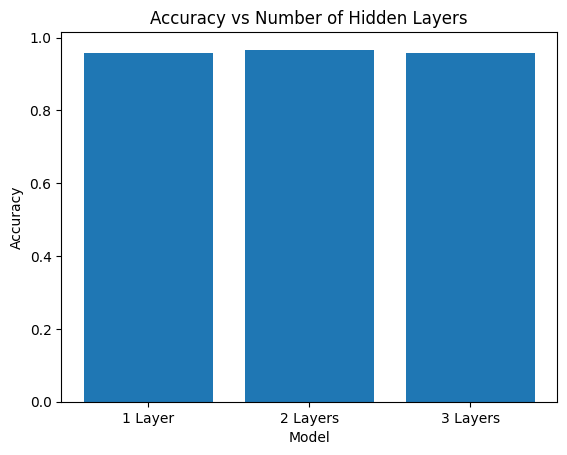

In [7]:
names = list(accuracies.keys())
values = list(accuracies.values())

plt.figure()
plt.bar(names, values)
plt.title("Accuracy vs Number of Hidden Layers")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

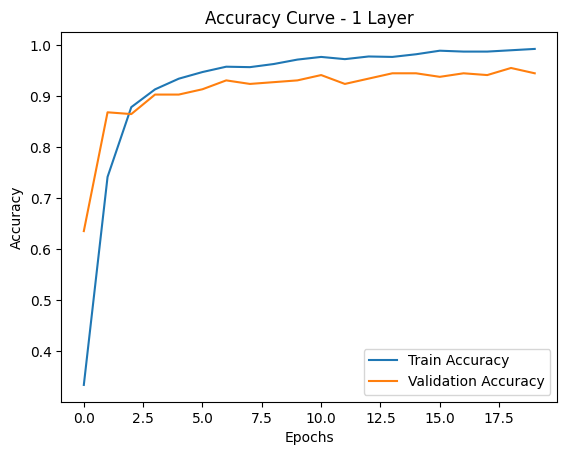

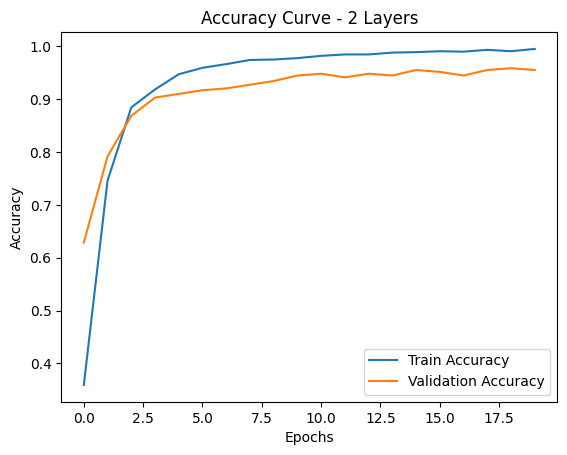

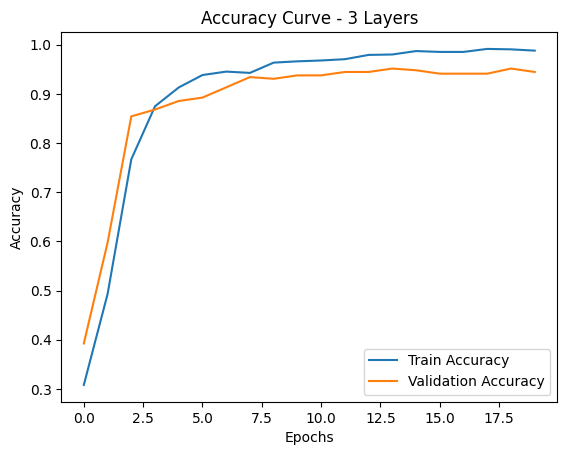

In [8]:
for name, history in histories.items():
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"Accuracy Curve - {name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()